In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive', exist_ok=True)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content

drive  sample_data


In [ ]:
!ls /content/drive

MyDrive  Othercomputers


In [ ]:
!ls "/content/drive/MyDrive"

'Acervo Digital'  'Colab Notebooks'
 CardioIA_Fase4   'DIL - Decision Intelligence Lab'


In [ ]:
!ls "/content/drive/MyDrive/CardioIA_Fase4"

'archive (1).zip'


In [ ]:
!unzip "/content/drive/MyDrive/CardioIA_Fase4/archive (1).zip" -d "/content/ecg_dataset"

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1869.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V187.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1870.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1871.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1872.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1874.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1877.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1879.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V188.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1880.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1881.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1882.png  
  inflating: /content/ecg_dataset/ECG_Image_data/train/V/V1883.png  
  inflating: /content/ecg_dataset/ECG_Image_da

In [ ]:
!ls /content/ecg_dataset

ECG_Image_data


In [ ]:
!ls /content/ecg_dataset/ECG_Image_data

test  train


In [ ]:
import os

train_path = "/content/ecg_dataset/ECG_Image_data/train"

print("=== CONJUNTO DE TREINO ===\n")

for classe in sorted(os.listdir(train_path)):
    pasta = os.path.join(train_path, classe)

    if os.path.isdir(pasta):
        qtd = len(os.listdir(pasta))
        print(f"Classe {classe}: {qtd} imagens")

=== CONJUNTO DE TREINO ===

Classe F: 642 imagens
Classe M: 8405 imagens
Classe N: 75709 imagens
Classe Q: 6431 imagens
Classe S: 2223 imagens
Classe V: 5789 imagens


In [ ]:
import os

test_path = "/content/ecg_dataset/ECG_Image_data/test"

print("=== CONJUNTO DE TESTE ===\n")

for classe in sorted(os.listdir(test_path)):
    pasta = os.path.join(test_path, classe)

    if os.path.isdir(pasta):
        qtd = len(os.listdir(pasta))
        print(f"Classe {classe}: {qtd} imagens")

=== CONJUNTO DE TESTE ===

Classe F: 153 imagens
Classe M: 2101 imagens
Classe N: 18926 imagens
Classe Q: 1608 imagens
Classe S: 556 imagens
Classe V: 1447 imagens


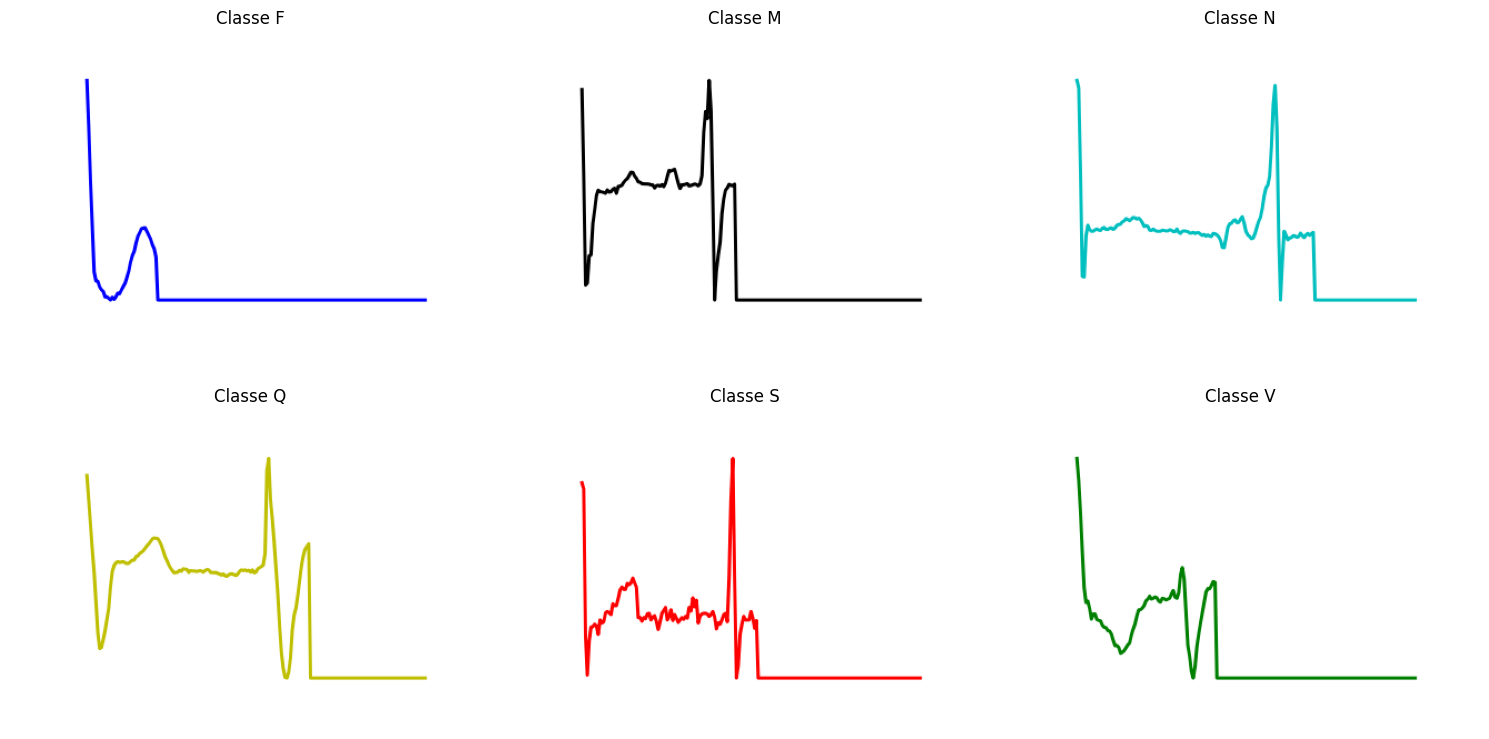

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_path = "/content/ecg_dataset/ECG_Image_data/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(15,8))

for i, classe in enumerate(classes):

    pasta = os.path.join(train_path, classe)

    imagem = random.choice(os.listdir(pasta))

    caminho = os.path.join(pasta, imagem)

    img = Image.open(caminho)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Classe {classe}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os
import random

train_path = "/content/ecg_dataset/ECG_Image_data/train"

classe = random.choice(os.listdir(train_path))
imagem = random.choice(os.listdir(os.path.join(train_path, classe)))

caminho = os.path.join(train_path, classe, imagem)

img = Image.open(caminho)

print("Classe:", classe)
print("Arquivo:", imagem)
print("Tamanho:", img.size)
print("Modo:", img.mode)

Classe: S
Arquivo: S2456.png
Tamanho: (432, 288)
Modo: RGBA


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_dir = "/content/ecg_dataset/ECG_Image_data/train"
test_dir = "/content/ecg_dataset/ECG_Image_data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 79362 images belonging to 6 classes.
Found 19837 images belonging to 6 classes.
Found 24791 images belonging to 6 classes.


In [ ]:
x_batch, y_batch = next(train_generator)

print("Formato das imagens:", x_batch.shape)
print("Formato dos rótulos:", y_batch.shape)

Formato das imagens: (32, 224, 224, 3)
Formato dos rótulos: (32, 6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Bloco 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

# Classificador
model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado com sucesso!")

Modelo compilado com sucesso!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "melhor_modelo.keras",
    monitor='val_accuracy',
    save_best_only=True
)

print("Callbacks configurados!")

Callbacks configurados!


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 323s 127ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 1.0000 - val_loss: 3.0078e-05
Epoch 2/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 310s 125ms/step - accuracy: 0.9983 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 4.7062e-05
Epoch 3/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 312s 126ms/step - accuracy: 0.9986 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 7.3844e-07
Epoch 4/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 304s 122ms/step - accuracy: 0.9994 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.0246e-08
Epoch 5/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 301s 121ms/step - accuracy: 0.9994 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 1.2865e-08
Epoch 6/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 296s 119ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 3.5335e-09
Epoch 7/10
2481/2481 ━━━━━━━━━━━━━━━━━━━━ 299s 121ms/step - accuracy: 0.9998 - loss: 7.2652e-04 - val_accuracy: 1.0000 - val_loss: 4.3268e-10
Epoch 8/10
2481/2481 ━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print("Loss:", test_loss)
print("Accuracy:", test_acc)

775/775 ━━━━━━━━━━━━━━━━━━━━ 70s 91ms/step - accuracy: 1.0000 - loss: 2.6447e-10
Loss: 2.6447072309920827e-10
Accuracy: 1.0


In [ ]:
print("Treino:")
print(train_generator.samples)

print("\nValidação:")
print(val_generator.samples)

print("\nTeste:")
print(test_generator.samples)

Treino:
79362

Validação:
19837

Teste:
24791


In [ ]:
print(train_generator.class_indices)

{'F': 0, 'M': 1, 'N': 2, 'Q': 3, 'S': 4, 'V': 5}


In [ ]:
import os

print("Treino V:")
print(len(os.listdir("/content/ecg_dataset/ECG_Image_data/train/V")))

print("Teste V:")
print(len(os.listdir("/content/ecg_dataset/ECG_Image_data/test/V")))

Treino V:
5789
Teste V:
1447


In [ ]:
import random
import os

train_v = random.choice(os.listdir("/content/ecg_dataset/ECG_Image_data/train/V"))
test_v  = random.choice(os.listdir("/content/ecg_dataset/ECG_Image_data/test/V"))

print("Treino:", train_v)
print("Teste :", test_v)

Treino: V157.png
Teste : V468.png


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predicoes = model.predict(test_generator)

y_pred = np.argmax(predicoes, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

775/775 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step
              precision    recall  f1-score   support

           F       1.00      1.00      1.00       153
           M       1.00      1.00      1.00      2101
           N       1.00      1.00      1.00     18926
           Q       1.00      1.00      1.00      1608
           S       1.00      1.00      1.00       556
           V       1.00      1.00      1.00      1447

    accuracy                           1.00     24791
   macro avg       1.00      1.00      1.00     24791
weighted avg       1.00      1.00      1.00     24791



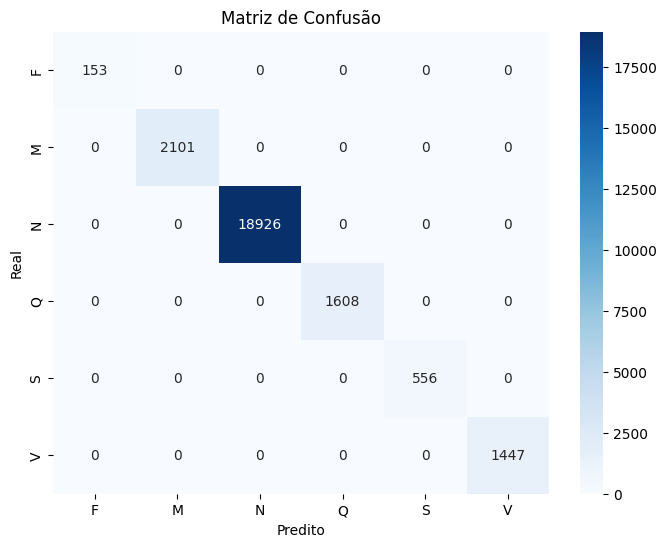

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
import hashlib
import os

def hash_file(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = set()

for classe in os.listdir("/content/ecg_dataset/ECG_Image_data/train"):
    pasta = os.path.join("/content/ecg_dataset/ECG_Image_data/train", classe)

    for arq in os.listdir(pasta):
        train_hashes.add(hash_file(os.path.join(pasta, arq)))

duplicados = 0

for classe in os.listdir("/content/ecg_dataset/ECG_Image_data/test"):
    pasta = os.path.join("/content/ecg_dataset/ECG_Image_data/test", classe)

    for arq in os.listdir(pasta):
        if hash_file(os.path.join(pasta, arq)) in train_hashes:
            duplicados += 1

print("Duplicados:", duplicados)

Duplicados: 4


In [ ]:
model.save("modelo_cardioia_fase4.h5")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find /content/drive/MyDrive -name "*.h5"

/content/drive/MyDrive/CardioIA_Fase4/modelo_cardioia_fase4.h5


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/CardioIA_Fase4/modelo_cardioia_fase4.h5"
)

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [ ]:
labels = {
    0: "F",
    1: "M",
    2: "N",
    3: "Q",
    4: "S",
    5: "V"
}

print(labels)

{0: 'F', 1: 'M', 2: 'N', 3: 'Q', 4: 'S', 5: 'V'}


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def prever_ecg(caminho_imagem):

    img = image.load_img(
        caminho_imagem,
        target_size=(224, 224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    pred = model.predict(img_array)

    classe = np.argmax(pred)

    confianca = np.max(pred)

    print("Classe prevista:", labels[classe])
    print("Confiança:", round(float(confianca) * 100, 2), "%")

In [ ]:
import os

for raiz, dirs, arquivos in os.walk("/content/ecg_dataset"):
    for arq in arquivos:
        if arq.endswith(".png"):
            print(os.path.join(raiz, arq))
            raise SystemExit

In [ ]:
import os

print(os.path.exists("/content/ecg_dataset"))
print(os.path.exists("/content"))

False
True


In [ ]:
!ls /content

drive  sample_data


In [ ]:
!find /content/drive/MyDrive -name "*.zip"

/content/drive/MyDrive/CardioIA_Fase4/archive (1).zip


In [ ]:
!unzip -q "/content/drive/MyDrive/CardioIA_Fase4/archive (1).zip" -d /content/

In [ ]:
!ls /content

drive  ECG_Image_data  sample_data


In [ ]:
import os

for raiz, dirs, arquivos in os.walk("/content/ECG_Image_data"):
    for arq in arquivos:
        if arq.endswith(".png"):
            print(os.path.join(raiz, arq))
            raise SystemExit

/content/ECG_Image_data/train/F/F173.png


SystemExit: 

In [ ]:
prever_ecg("/content/ECG_Image_data/train/F/F173.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classe prevista: F
Confiança: 100.0 %


In [1]:
!ls -lh /content
!ls -lh /content/drive/MyDrive/CardioIA_Fase4

total 4.0K
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data
ls: cannot access '/content/drive/MyDrive/CardioIA_Fase4': No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls "/content/drive/MyDrive"

'Acervo Digital'  'Colab Notebooks'
 CardioIA_Fase4   'DIL - Decision Intelligence Lab'


In [4]:
!ls "/content/drive/MyDrive/CardioIA_Fase4"

'archive (1).zip'   modelo_cardioia_fase4.h5


In [5]:
!find "/content/drive/MyDrive/CardioIA_Fase4" -type f | head -50

/content/drive/MyDrive/CardioIA_Fase4/archive (1).zip
/content/drive/MyDrive/CardioIA_Fase4/modelo_cardioia_fase4.h5


In [6]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "*Cardio*"

/content/drive/MyDrive/Colab Notebooks/cardioia_ia_temporal.ipynb
/content/drive/MyDrive/Colab Notebooks/CardioIA_Fase4_Preprocessamento_FINAL.ipynb
